In [1]:
# Import Libraries
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import sgt_csv_to_dataframe, sgt_spider_plot

In [2]:
# Read data from files
allowed_ext = ".csv"
csv_dir_path = "1um/"
pdf_file = "scaling_results.pdf"
plt_figs = []

all_sheets = sgt_csv_to_dataframe(csv_dir_path, delimiter=",")
print(all_sheets.keys())

dict_keys(['ARImGr0S1_1', 'ARImGr0S1_2', 'ARImGr0S1_3', 'ARImGr0S1_4', 'ARImGr0S2_1', 'ARImGr0S2_2', 'ARImGr0S2_3', 'ARImGr0S2_4', 'ARImGr0S3_1', 'ARImGr0S3_2', 'ARImGr0S3_3', 'ARImGr0S3_4', 'ARImGr0S4_1', 'ARImGr0S4_2', 'ARImGr0S4_3', 'ARImGr0S4_4', 'ARImGr0S5_1', 'ARImGr0S5_2', 'ARImGr0S5_3', 'ARImGr0S5_4', 'ARImGr0S6_1', 'ARImGr0S6_2', 'ARImGr0S6_3', 'ARImGr0S6_4', 'ARImGr0S7_1', 'ARImGr0S7_2', 'ARImGr0S7_3', 'ARImGr0S7_4', 'ARImGr0S8_1', 'ARImGr0S8_2', 'ARImGr0S8_3', 'ARImGr0S8_4', 'ARImGr0S9_1', 'ARImGr0S9_2', 'ARImGr0S9_3', 'ARImGr0S9_4'])


In [3]:
# Filter SGT parameters
materials = ['ARImGr0S1', 'ARImGr0S2', 'ARImGr0S3', 'ARImGr0S4', "ARImGr0S5", "ARImGr0S6", "ARImGr0S7", "ARImGr0S8", "ARImGr0S9"]
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']


In [4]:
all_sheets['ARImGr0S1_1']

,parameter,value
0,Number of nodes,1391.00000
1,Number of edges,1777.00000
2,Average edge angle (degrees),160.49700
3,Median edge angle (degrees),85.42600
4,Average degree,2.55500
5,Network diameter,64.00000
6,Graph density,0.00184
7,Global efficiency,0.05397
8,Assortativity coefficient,-0.06910
9,Average clustering coefficient,0.03091


In [5]:
# Combine the 4 sections for each material into 1 DataFrame (to be averaged)

all_avg_dfs = {}

for mat_label in materials:
    avg_df = None
    i = 1
    for key, df in all_sheets.items():
        if key.startswith(mat_label):
            temp_df = df.copy()
            temp_df.rename(columns={'value': f'value-{i}'}, inplace=True)
            if avg_df is None:
                avg_df = temp_df
            else:
                avg_df = pd.merge(avg_df, temp_df, on='parameter', how='inner')
            i += 1

    if avg_df is not None:
        avg_df.insert(0, "Material", mat_label)
        all_avg_dfs[mat_label] = avg_df

In [6]:
grp_avg_df = {}

df_sec_1 = pd.concat([all_avg_dfs['ARImGr0S1'], all_avg_dfs['ARImGr0S2'], all_avg_dfs['ARImGr0S3']], ignore_index=True)
df_sec_2 = pd.concat([all_avg_dfs['ARImGr0S4'], all_avg_dfs['ARImGr0S5'], all_avg_dfs['ARImGr0S6']], ignore_index=True)
df_sec_3 = pd.concat([all_avg_dfs['ARImGr0S7'], all_avg_dfs['ARImGr0S8'], all_avg_dfs['ARImGr0S9']], ignore_index=True)

In [7]:
val_cols = ["value-1", "value-2", "value-3", "value-4"]
lst_compare = [
    ['ARImGr0S1', 'ARImGr0S4'],
    ['ARImGr0S2', 'ARImGr0S5'],
    ['ARImGr0S3', 'ARImGr0S6'],
    ['ARImGr0S4', 'ARImGr0S7'],
    ['ARImGr0S5', 'ARImGr0S8'],
    ['ARImGr0S6', 'ARImGr0S9']
]
all_avg_dfs['ARImGr0S1']

,Material,parameter,value-1,value-2,value-3,value-4
0,ARImGr0S1,Number of nodes,1391.00000,1356.00000,1112.00000,1500.00000
1,ARImGr0S1,Number of edges,1777.00000,1754.00000,1395.00000,2052.00000
2,ARImGr0S1,Average edge angle (degrees),160.49700,165.60800,158.31000,153.17400
3,ARImGr0S1,Median edge angle (degrees),85.42600,87.27400,84.80600,84.91800
4,ARImGr0S1,Average degree,2.55500,2.58702,2.50899,2.73600
5,ARImGr0S1,Network diameter,64.00000,61.00000,58.00000,67.00000
6,ARImGr0S1,Graph density,0.00184,0.00191,0.00226,0.00183
7,ARImGr0S1,Global efficiency,0.05397,0.05630,0.05991,0.05149
8,ARImGr0S1,Assortativity coefficient,-0.06910,-0.09637,-0.11493,0.05715
9,ARImGr0S1,Average clustering coefficient,0.03091,0.02706,0.02233,0.03429


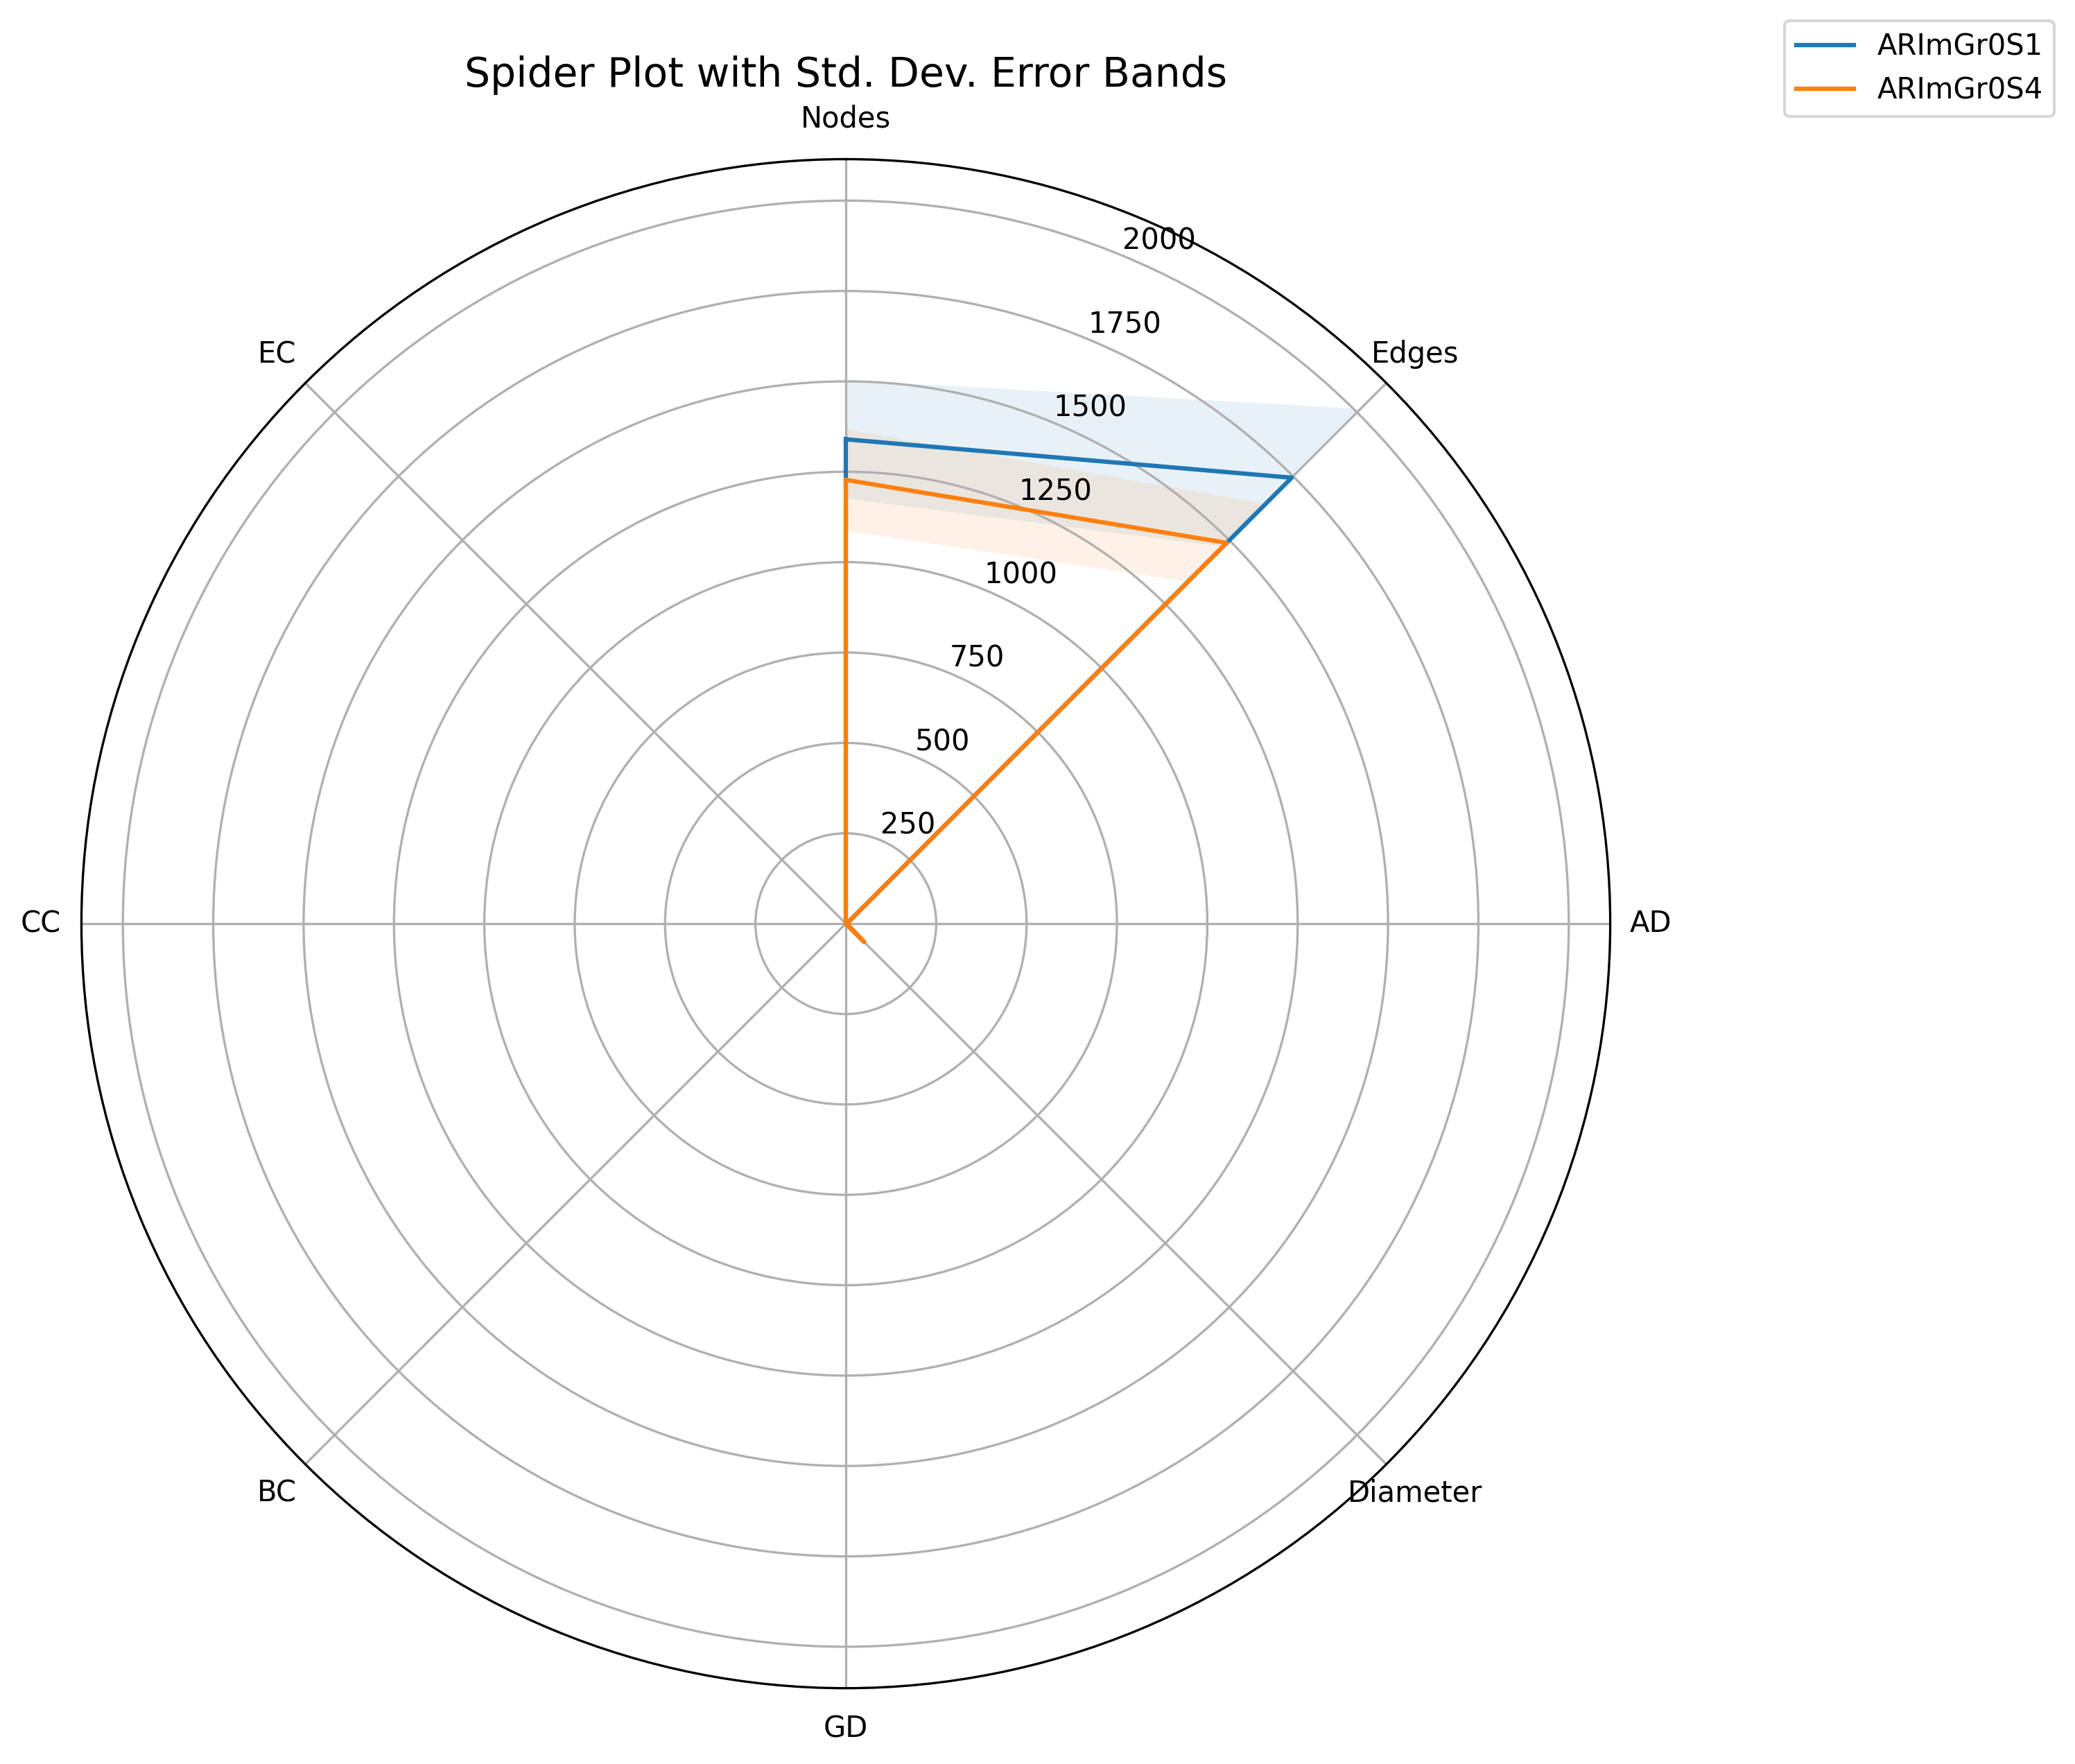

In [16]:
"""
Spider Plot: S1-S4
"""

df_sgt = pd.concat([all_avg_dfs['ARImGr0S1'], all_avg_dfs['ARImGr0S4']], ignore_index=True)
plt_fig = sgt_spider_plot(df_sgt, ['ARImGr0S1', 'ARImGr0S4'], parameters, value_cols=val_cols)
plt_figs.append(plt_fig)

In [17]:
df_sgt

,parameter,value-1,value-2,value-3,value-4,Material,Avg.,Std. Dev.
0,Nodes,1391.00000,1356.00000,1112.00000,1500.00000,ARImGr0S1,1339.750000,163.748537
1,Edges,1777.00000,1754.00000,1395.00000,2052.00000,ARImGr0S1,1744.500000,269.476653
2,Avg. E. Angle,160.49700,165.60800,158.31000,153.17400,ARImGr0S1,159.397250,5.154086
3,Med. E. Angle,85.42600,87.27400,84.80600,84.91800,ARImGr0S1,85.606000,1.144256
4,AD,2.55500,2.58702,2.50899,2.73600,ARImGr0S1,2.596753,0.098201
5,Diameter,64.00000,61.00000,58.00000,67.00000,ARImGr0S1,62.500000,3.872983
6,GD,0.00184,0.00191,0.00226,0.00183,ARImGr0S1,0.001960,0.000203
7,GE,0.05397,0.05630,0.05991,0.05149,ARImGr0S1,0.055418,0.003582
8,ASC,-0.06910,-0.09637,-0.11493,0.05715,ARImGr0S1,-0.055812,0.077625
9,ACC,0.03091,0.02706,0.02233,0.03429,ARImGr0S1,0.028647,0.005144
